In [1]:
# Author: Saurabh
import numpy as np
import matplotlib.pyplot as plt
import pywt
import os
import sys
import pandas as pd

# Provide system path for utility class
sys.path.append(os.path.abspath('D:\\AODD_Pump_wavelet_analysis\\Utilities'))
from utilities import Utility

In [4]:
def main():
    utility = Utility()
    # User Inputs
    level = 4
    wavelet = 'db3'
    label_list = ['12 Oct', '14 Oct', '15 Oct', '16 Oct', '17 Oct', '18 Oct', '19 Oct']
    colors = ['g', 'b', 'm', 'g', 'b', 'm', 'k']
    # label_list = ['20 Oct', '21 Oct', '21 Oct']
    # colors = ['b', 'm', 'k']
    # label_list = ['18 Jul', '19 Jul', '20 Jul', '21 Jul', '22 Jul', '23 Jul']
    # colors = ['g', 'b', 'm', 'k', 'c', 'r']
    fixed_len = 2000  ##(This represents 1 min data)
    # Import readings
    parquet_data_set = \
        [
            'D:\\2 inch Pump CSV Files\\P1_Validation-3_CSV File\\01_P1_Validation-3_20Oct23.csv',
            'D:\\2 inch Pump CSV Files\\P1_Validation-3_CSV File\\02_P1_Validation-3_21Oct23.csv',
            'D:\\2 inch Pump CSV Files\\P1_Validation-3_CSV File\\03_P1_Validation-3_22Oct23.csv',
            ]

    # parquet_data_set = \
    #     [
    #         'C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/T07_P1_20 2/01_P1_Validation-3_20Oct23.parquet',
    #         'C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/T07_P1_20 2/02_P1_Validation-3_21Oct23.parquet',
    #         'C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/T07_P1_20 2/03_P1_Validation-3_22Oct23.parquet'
    #         ]

    # parquet_data_set = \
    #     ['C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/D4 Test 2 inch pump/01_P1_20_ASP100_WDP50_18Jul24.parquet',
    #     'C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/D4 Test 2 inch pump/02_P1_20_ASP100_WDP50_19Jul24.parquet',
    #     'C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/D4 Test 2 inch pump/03_P1_20_ASP100_WDP50_20Jul24.parquet',
    #     'C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/D4 Test 2 inch pump/04_P1_20_ASP100_WDP50_21Jul24.parquet',
    #     'C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/D4 Test 2 inch pump/05_P1_20_ASP100_WDP50_22Jul24.parquet',
    #     'C:/Users/11055244/Projects_Technical/Projects/2024/CMS of AODD pump/Data/D4 Test 2 inch pump/06_P1_20_ASP100_WDP50_23Jul24.parquet'
    #     ]
    entire_data = []
    entire_data_mean = []

    # Reading and performing analysis on each file
    for itr in enumerate (parquet_data_set):
        parquet_file_path = itr[1]
        df_par_old = pd.read_csv(parquet_file_path)
        if df_par_old is None:
            continue
        else:
            df_par = df_par_old[df_par_old['P1-Air-Supply-pressure'] >= 85]
            df_par['Time'] = df_par['Time'].astype('datetime64[ns]')

        total_len = len(df_par)
        x = total_len/fixed_len
        x = int(np.ceil(x))

        # plt.figure(figsize=(10, 10))
        # plt.subplot(2, 1, 1)
        # plt.scatter(df_par['Time'], df_par['P1-Air-Supply-pressure'])
        # # plt.plot(df_par['Time'], df_par['P1-Air-Supply-pressure'])
        # plt.ylabel('P1-Air supply pressure')
        # plt.subplot(2, 1, 2)
        # plt.plot(df_par['Time'], df_par['P1-CPM'])
        # plt.xlabel('Time')
        # plt.ylabel('P1-CPM')
        # plt.tight_layout()
        # plt.ylim(0, 65)
        # plt.xticks(rotation=0)
        # plt.show()

        # Generate array to store transformed signal
        stddev = [[] for _ in range(level)]
        mean = [[] for _ in range(level)]

        # Chopping entire length into fixed size segments (equivalent to 1 min long data 2000 data points)
        for discre_data in range(1, x+1):
            if discre_data == x:
                healthy_data_s = df_par[1+fixed_len*(discre_data-1):]
            else:
                healthy_data_s = df_par[1+fixed_len*(discre_data-1):fixed_len*discre_data]

            # time = healthy_data_s['Time']
            signal = healthy_data_s['P1-Air-Supply-pressure']
            Recon_healthy_s1_IAP = utility.take_wavelet(wavelet, level, signal, 'AIP healthy s1')
            for decom_iter in range(1, level+1):
                decomposed_data_set = Recon_healthy_s1_IAP[decom_iter]
                mean[decom_iter - 1].append(np.mean(decomposed_data_set))
                stddev[decom_iter-1].append(np.std(decomposed_data_set))

        entire_data.append(stddev)
        entire_data_mean.append(mean)

    # plt.figure(figsize=(10, 6))
    #
    # for idx, sublist in enumerate(entire_data):
    #     for jdx, item in enumerate(sublist):
    #         # plt.plot(sublist, color=colors[idx], label=label_list[idx])
    #         plt.plot(item, color=colors[jdx], label=label_list[jdx])
    # plt.xlabel('Index')
    # plt.ylabel('StdDev')
    # plt.tight_layout()
    # plt.show()

    # plt.figure(figsize=(20, 20))
    # for d_iter in range(0, level):
    #     for file_iter in range(0, len(parquet_data_set)):
    #         plt.plot(entire_data[file_iter][d_iter], color=colors[file_iter], label=label_list[file_iter])
    #     plt.xlabel('Index')
    #     plt.ylabel('StdDev')
    #     plt.title(['Decomposed level {}'.format(str(d_iter+1))])
    #     plt.tight_layout()
    #     plt.show()

    # vec_gradient = []
    # #Compute the metric
    # # for m_iter in range(0, level):
    # for idx, sublist in enumerate(entire_data):
    #     value = utility.moving_avg(sublist, 0)
    #     # first_derivative = np.diff(sublist[1])
    #     vec_gradient.append(value)
    #
    # x_start = 0
    # # for d_iter in range(0, level):
    # for idx, sublist in enumerate(entire_data):
    #     x_end = x_start + len(vec_gradient[idx])
    #     x_values = range(x_start, x_end)
    #     # plt.plot(x_values, sublist[d_iter], color=colors[idx], label=label_list[idx])
    #     plt.plot(x_values, vec_gradient[idx], color=colors[idx], label=label_list[idx])
    #     # utility.plot_with_plotly(x_values, sublist[d_iter], plot_path='plot.html', label=label_list[idx])
    #     x_start = x_end
    # plt.xlabel('Index')
    # plt.ylabel('StdDev')
    # # plt.title('Sequential plot of 6 days with different color D-{}'.format(d_iter + 1))
    # plt.legend(loc='best')
    # plt.tight_layout()
    # plt.show()

    plt.figure(figsize=(10, 8))
    x_start = 0
    for d_iter in range(0, level):
        for idx, sublist in enumerate(entire_data):
            x_end = x_start + len(sublist[d_iter])
            x_values = range(x_start, x_end)
            plt.plot(x_values, sublist[d_iter], color=colors[idx], label=label_list[idx])
            # plt.plot(vec_gradient[idx], color=colors[idx], label=label_list[idx])
            # utility.plot_with_plotly(x_values, sublist[d_iter], plot_path='plot.html', label=label_list[idx])
            x_start = x_end
        plt.xlabel('Index')
        plt.ylabel('StdDev')
        plt.title('Sequential plot of 6 days with different color D-{}'.format(d_iter+1))
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()


    x_start = 0
    for d_iter in range(0, level):
        for idx, sublist in enumerate(entire_data_mean):
            x_end = x_start + len(sublist[d_iter])
            x_values = range(x_start, x_end)
            plt.plot(x_values, sublist[d_iter], color=colors[idx], label=label_list[idx])
            x_start = x_end
        plt.xlabel('Index')
        plt.ylabel('mean')
        plt.title('Sequential plot of 6 days with different color D-{}'.format(d_iter + 1))
        plt.legend(loc='best')
        plt.tight_layout()
        plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_12924\2509707517.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_par['Time'] = df_par['Time'].astype('datetime64[ns]')
C:\Users\Admin\AppData\Local\Temp\ipykernel_12924\2509707517.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_par['Time'] = df_par['Time'].astype('datetime64[ns]')


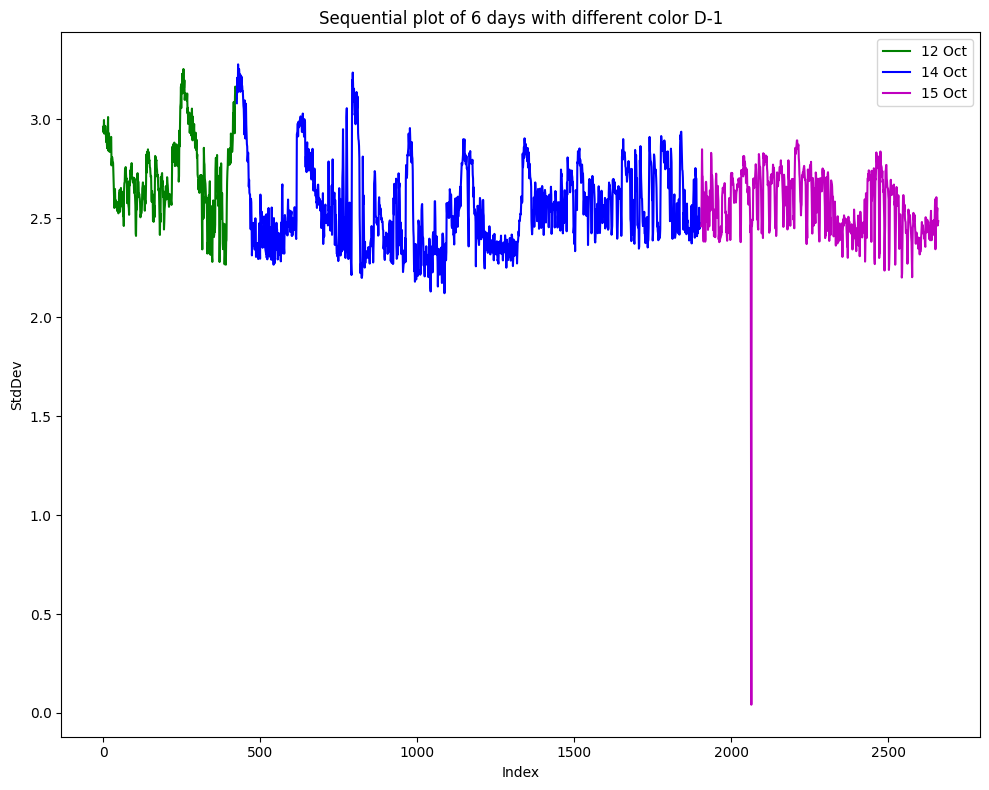

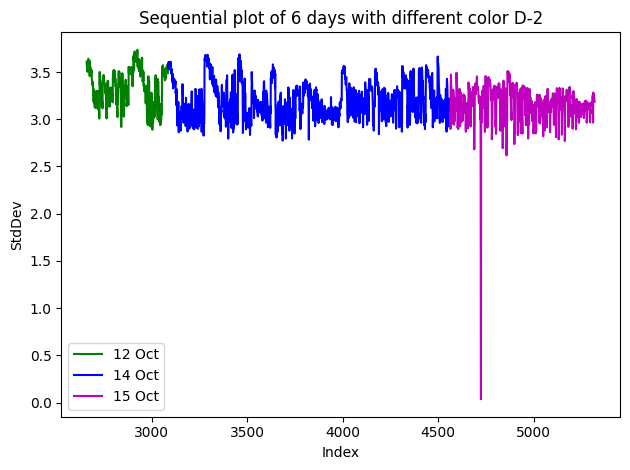

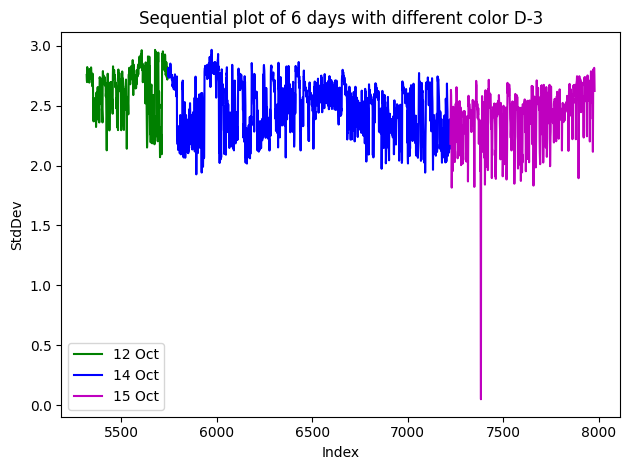

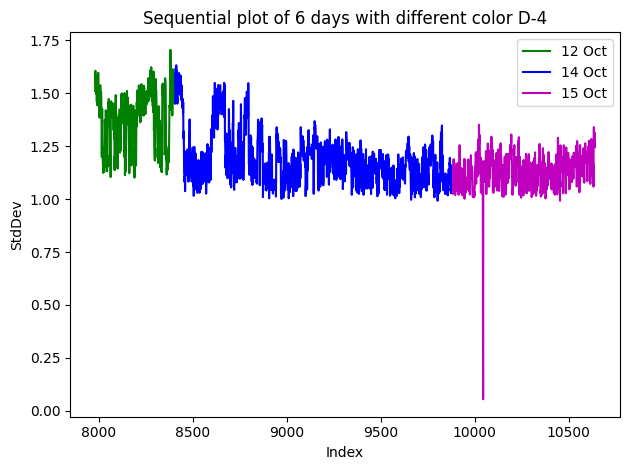

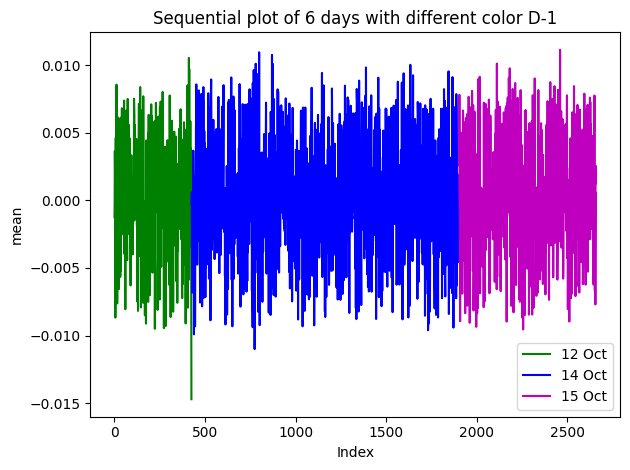

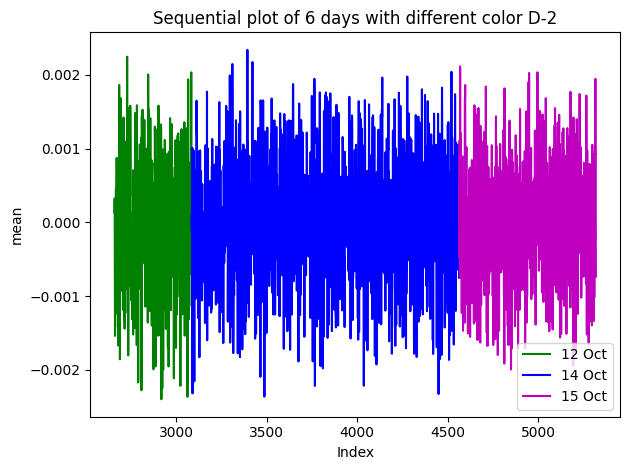

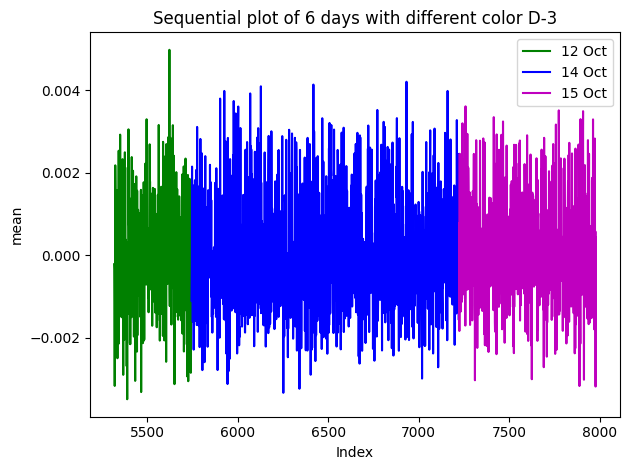

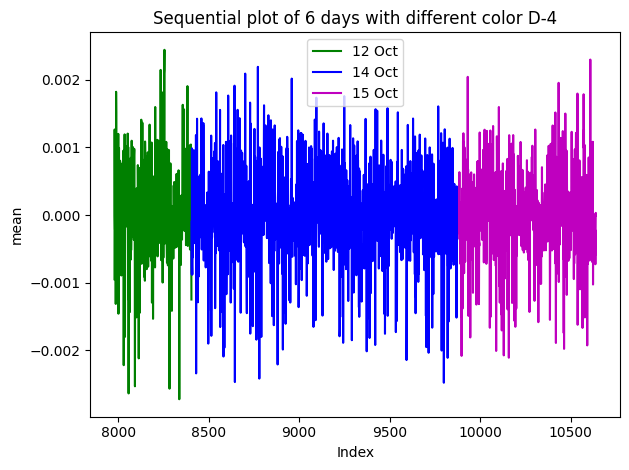

In [6]:
if __name__ == '__main__':
    main();